In [84]:
import pandas as pd
import numpy as np
import os
import datetime as dt
import missingno as msno
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
from skimpy import skim
import scipy.stats as stats


### Data frame creator

In [85]:
df_polish = pd.read_csv('../data/smog_polishraw.csv', encoding='utf-8-sig')
#df_smog = pd.read_csv('../data/smog_raw.csv', encoding='utf-8-sig')
df_smog = pd.read_csv('../data/smog_polishraw.csv', encoding='utf-8-sig')
df_smog2 = pd.read_csv('../data/smog_raw2.csv', encoding='utf-8-sig')


### Pokazanie czy działa formatowanie - brak błędów polskich znaków - niestety nie potrafie naprawić

In [ ]:
print(df_smog['NAME'].head())


### Nazwy nagłówków

In [ ]:
print(df_smog.columns)


### Opis danych [wszystkie dane wypisane jako bool]

In [ ]:
df_smog.isna().info()


### Opis typu danych w kolumnach

In [70]:
print(df_smog.dtypes)


NAME                   str
STREET                 str
POST_CODE              str
CITY                   str
LONGITUDE          float64
LATITUDE           float64
HUMIDITY_AVG           str
PRESSURE_AVG           str
TEMPERATURE_AVG        str
PM10_AVG           float64
PM25_AVG           float64
TIMESTAMP              str
TYLKO_DATA          object
TYLKO_CZAS          object
dtype: object


### Zmiana typu danych w kolumnie 'Date' na datetime

In [33]:
df_smog['TIMESTAMP_DATETIME'] = pd.to_datetime(df_smog['TIMESTAMP'], errors='coerce')


### Wyciągam datę

In [69]:
df_smog['TYLKO_DATA'] = df_smog['TIMESTAMP_DATETIME'].dt.date


KeyError: 'TIMESTAMP_DATETIME'

### Wyciągamy sam czas (Format: GG:MM:SS)

In [35]:
df_smog['TYLKO_CZAS'] = df_smog['TIMESTAMP_DATETIME'].dt.time


### Usuwamy kolumnę pomocniczą

In [36]:
df_smog = df_smog.drop(columns=['TIMESTAMP_DATETIME'])


### Podgląd danych po zmianie formatowania daty i czasu

In [37]:
print(df_smog['TYLKO_CZAS'].head())


0    20:22:18
1    20:22:18
2    20:22:18
3    20:22:18
4    20:22:18
Name: TYLKO_CZAS, dtype: object


### Podgląd nazw nagłówków w tabeli

In [38]:
df_smog.head(2)


,NAME,STREET,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS
0,SZKOŁA PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...,UL. SZKOLNA,63-522,KRASZEWICE,18.22403,51.51563,99.90000000000002,1010.5666666666666,24.233333333333334,0.000,0.000000,2026-07-03 20:22:18,2026-07-03,20:22:18
1,SZKOŁA PODSTAWOWA WE WRZĄSOWICACH,UL. SZKOLNA,32-040,WRZĄSOWICE,19.94282,49.96103,35.6,980.3249999999999,22.641666666666666,1.625,1.266667,2026-07-03 20:22:18,2026-07-03,20:22:18


### Podstawowe statystyki opisowe [według typów danych]

In [ ]:
df_smog.describe()


Statystyki

In [ ]:
display(df_smog.describe())


Pokaż braki

In [ ]:
print(df_smog.isnull().sum())


Pokaż dane temperatury

In [ ]:
df_smog.sort_values(['TEMPERATURE_AVG']).head(10)


Czyszczenie błędów w danych - temperatura powinna byc powyżej >10 stopni celc [ do naprawy]

In [131]:
#df_smog = df_smog[df_smog['TEMPERATURE_AVG'] >= 10]


Usuwanie wierszy z brakami w lokalizacjach

In [159]:
df_smog = df_smog[(df_smog['LATITUDE'] != 0) & (df_smog['LONGITUDE'] != 0)]


### Mapa braków

In [ ]:
sns.heatmap(df_smog.isna())


Przyczyny braku

In [ ]:
msno.matrix(df_smog)


Przyczyny braków

In [ ]:
msno.heatmap(df_smog)


### Set variables

In [12]:
area_dict = {
    range(0, 10): 'Mazowieckie',
    range(10, 15): 'Warmińsko-mazurskie',
    range(15, 20): 'Podlaskie',
    range(20, 25): 'Lubelskie',
    range(25, 29): 'Świętokrzyskie',
    range(30, 35): 'Małopolskie',
    range(35, 40): 'Podkarpackie',
    range(40, 45): 'Śląskie',
    range(45, 50): 'Opolskie',
    range(50, 60): 'Dolnośląskie',
    range(60, 65): 'Wielkopolskie',
    range(66, 70): 'Lubuskie',
    range(70, 79): 'Zachodniopomorskie',
    range(80, 85): 'Pomorskie',
    range(86, 90): 'Kujawsko-pomorskie',
    range(90, 98): 'Łódzkie'
}
smog_columns = ['LONGITUDE', 'LATITUDE', 'HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG', 'PM10_AVG', 'PM25_AVG']


# Insert area column based on post code

In [5]:
df_smog.insert(2, 'AREA', df_smog['POST_CODE'].astype(str).str[:3].astype(int))


In [ ]:
df_smog['AREA'].head(20)


In [30]:
for x in area_dict:
    for y, z in df_smog['AREA'].items():
        if z in x:
            df_smog['AREA'] = area_dict.get(x)


In [ ]:
df_smog


In [ ]:
for x in area_dict:
    for y in df_smog['AREA'].items():
        if value in x:
            value = y
    print(df_smog['AREA'])


Dendogram

In [ ]:
msno.dendrogram(df_smog)


### Format float values with precission to 1 [ Convert values to float]

In [138]:
#for x in smog_columns:
    #for z, y in df_smog[f"{x}"].items():
       # y = float(y)
    #df_smog[f"{x}"] = float(df_smog[f"{x}"]).round(1)    
    #df_smog2[f"{x}"] = df_smog2[f"{x}"].round(1)


### Strip '-' from post code

In [139]:
for x in df_smog['POST_CODE']:
    df_smog['POST_CODE'] = df_smog['POST_CODE'].str.replace("-", "")
    df_smog2['POST_CODE'] = df_smog2['POST_CODE'].str.replace("-", "")


In [46]:
df_smog.head(5)


,NAME,STREET,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS
0,SZKOŁA PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...,UL. SZKOLNA,63-522,KRASZEWICE,18.224030,51.515630,99.90000000000002,1010.5666666666666,24.233333333333334,0.000000,0.000000,2026-07-03 20:22:18,2026-07-03,20:22:18
1,SZKOŁA PODSTAWOWA WE WRZĄSOWICACH,UL. SZKOLNA,32-040,WRZĄSOWICE,19.942820,49.961030,35.6,980.3249999999999,22.641666666666666,1.625000,1.266667,2026-07-03 20:22:18,2026-07-03,20:22:18
2,ZESPÓŁ SZKÓŁ NR 1 W PSZCZYNIE,UL. KAZIMIERZA WIELKIEGO,43-200,PSZCZYNA,18.945706,49.965883,31.666666666666668,1003.1333333333333,28.400000000000002,0.033333,0.020000,2026-07-03 20:22:18,2026-07-03,20:22:18
3,ZESPÓŁ SZKÓŁ IM. POWSTAŃCÓW WIELKOPOLSKICH W J...,SZKOLNA,63-421,JANKÓW PRZYGODZKI,17.788907,51.596172,99.90000000000002,992.4,16.4,21.300000,11.150000,2026-07-03 20:22:18,2026-07-03,20:22:18
4,SZKOŁA PODSTAWOWA NR 7 IM. ŻOŁNIERZY WRZEŚNIA ...,UL. MĘCZENNIKÓW OŚWIĘCIMSKICH,43-229,ĆWIKLICE,18.989839,49.971937,55.63333333333333,989.3000000000001,22.166666666666668,0.766667,0.413333,2026-07-03 20:22:18,2026-07-03,20:22:18


In [ ]:
df_smog2.tail(5)


### Shape after first format

In [ ]:
df_smog.shape


In [ ]:
df_smog2.shape


### Data frame look

In [ ]:
df_smog.head(5)


In [ ]:
df_smog2.tail(5)


### -[] Set missing values to 0 in smog_columns 

In [160]:
for x in smog_columns:
    if df_smog[f"{x}"].any() == 0.0:
        print(df_smog[f"{x}"])
        #print(df_smog2[f"{x}"])
        #df_smog[f"{x}"] = df_smog2[f"{x}"]
    #print(df_smog[f"{x}"].isna().sum())


### Check, if every area is in place (longitude and latitude are in Polish area)

In [ ]:
# Define a function and area latitude and longitude min and max values
for y, x in df_smog['LATITUDE'].items() and df_smog['LONGITUDE'].items():
    x = float(x)

def check_areas(df):
    area_values = {
        "Latitude.North < 54.835563": df_smog['LATITUDE'] < 54.8,
        "Latitude.South > 49.002063": df_smog['LATITUDE'] > 49.0,
        "Longitude.East < 24.145562": df_smog['LONGITUDE'] < 24.2,
        "Longitude.West > 14.124562": df_smog['LONGITUDE'] > 14.0
        }
    return area_values

# Define an object table with the area checker

areas = check_areas(df_smog)

# Print if there are any differences in the areas

for rule, result in areas.items():
    print(f"{rule}: {not result.all()}")


### Check, how many of areas have wrong latitudes\longitudes

In [ ]:
# Check, how many differences are in areas

differences = {rule: ~result for rule, result in areas.items()}
summary = {rule: result.sum() for rule, result in differences.items()}

# Print the number of differences

for rule, count in summary.items():
    print(f"{rule}: {count} differences")


Szukanie korelacji

<Axes: xlabel='POST_CODE', ylabel='PM10_AVG'>

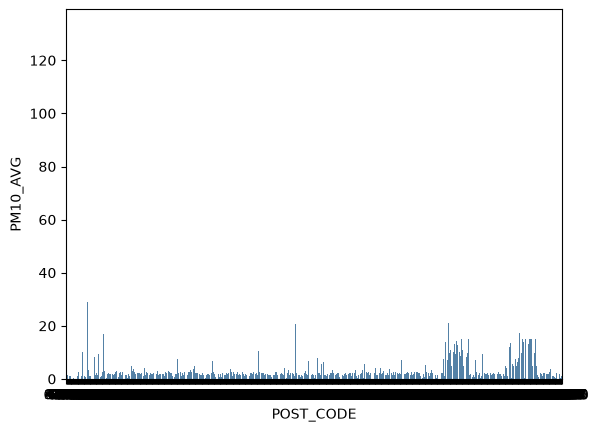

In [55]:
sns.barplot(data=df_smog,x='POST_CODE',y='PM10_AVG',errorbar=None,estimator=np.mean,color='steelblue')


<Axes: xlabel='TEMPERATURE_AVG', ylabel='PM10_AVG'>

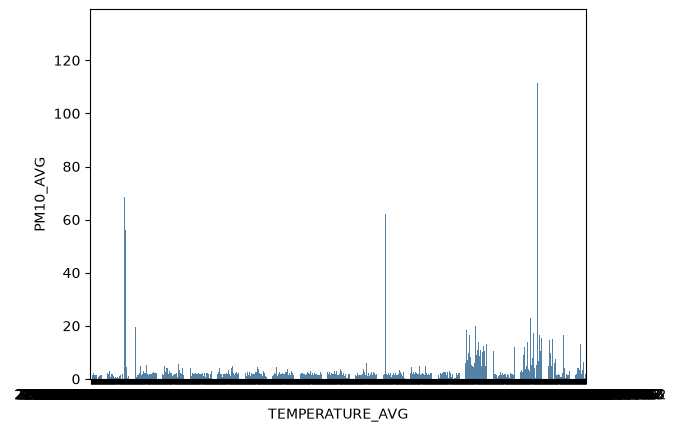

In [56]:
sns.barplot(data=df_smog,x='TEMPERATURE_AVG',y='PM10_AVG',errorbar=None,estimator=np.mean,color='steelblue')


In [57]:
korelacje = df_smog.corr(numeric_only=True)


In [58]:
plt.figure(figsize=(10, 8))


<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: >

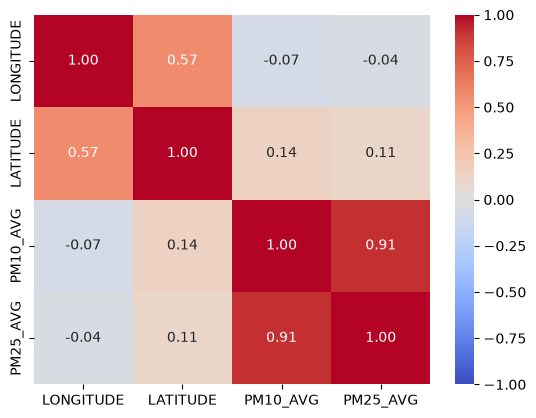

In [59]:
sns.heatmap(korelacje, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)


Usuwanie duplikatów

In [60]:
korelacje_lista = korelacje.unstack().sort_values(key=abs, ascending=False).drop_duplicates()


In [61]:
korelacje_lista = korelacje_lista[korelacje_lista != 1.0]


In [62]:
print("Najsilniejsze znalezione korelacje w danych:")


Najsilniejsze znalezione korelacje w danych:


In [63]:
print(korelacje_lista.head(10))


PM10_AVG   PM25_AVG     0.912949
LATITUDE   LONGITUDE    0.566783
PM10_AVG   LATITUDE     0.136255
LATITUDE   PM25_AVG     0.107007
PM10_AVG   LONGITUDE   -0.066022
LONGITUDE  PM25_AVG    -0.040147
dtype: float64


Histogramy dla PM10

Text(0.5, 0, 'Wartość PM10')

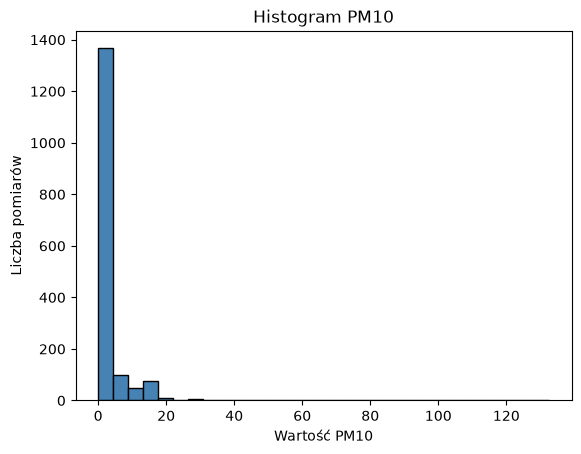

In [64]:
p=plt.hist(df_smog['PM10_AVG'], bins=30, color='steelblue', edgecolor='black')
plt.ylabel('Liczba pomiarów')
plt.title('Histogram PM10')
plt.xlabel('Wartość PM10')


Wykres rozrzutu

Text(0.5, 1.0, 'Wykres rozrzutu PM10 vs PM2.5')

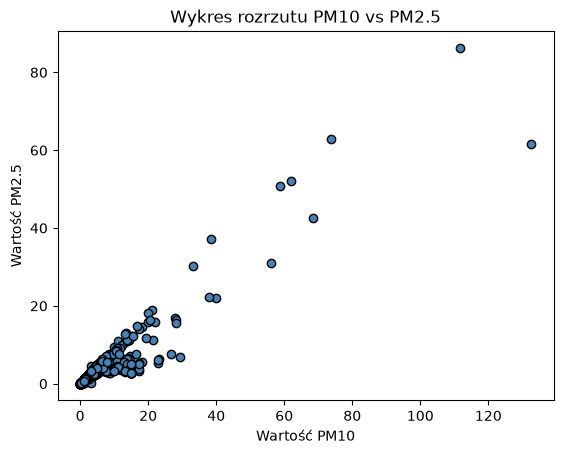

In [66]:
p=plt.scatter(df_smog['PM10_AVG'], df_smog['PM25_AVG'], color='steelblue', edgecolor='black')
plt.xlabel('Wartość PM10')
plt.ylabel('Wartość PM2.5')
plt.title('Wykres rozrzutu PM10 vs PM2.5')


Wykres rozrzutu

<Axes: xlabel='PM10_AVG', ylabel='Probability'>

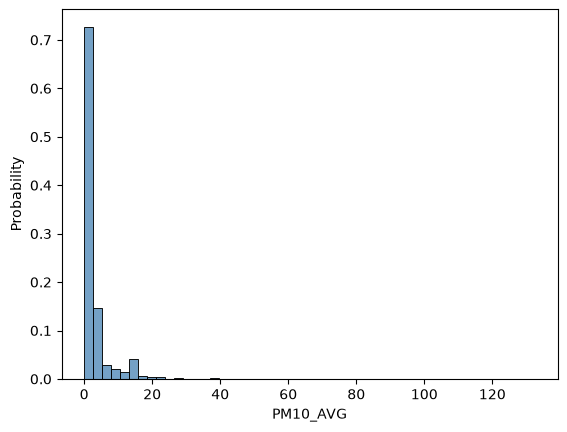

In [80]:
sns.histplot(data=df_smog, x='PM10_AVG',stat='probability', bins=50, color='steelblue', edgecolor='black')


Wykres rozrzutu

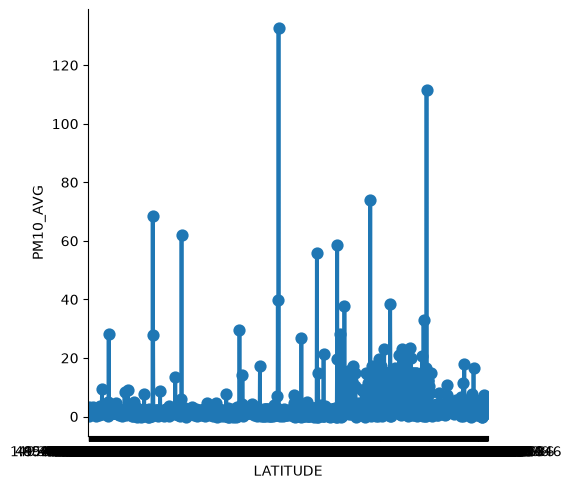

In [ ]:
sns.catplot(data=df_smog,x='LATITUDE',y=PM10_AVG',kind='point')


Analiza opisowa

<Axes: xlabel='TEMPERATURE_AVG', ylabel='PM25_AVG'>

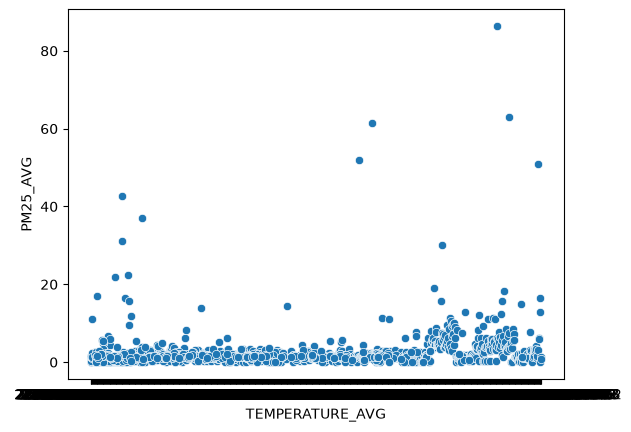

In [81]:
sns.scatterplot(data=df_smog, x='TEMPERATURE_AVG', y='PM25_AVG')       


Rozrzut PM10 wg temperatury

<Axes: xlabel='TEMPERATURE_AVG', ylabel='PM10_AVG'>

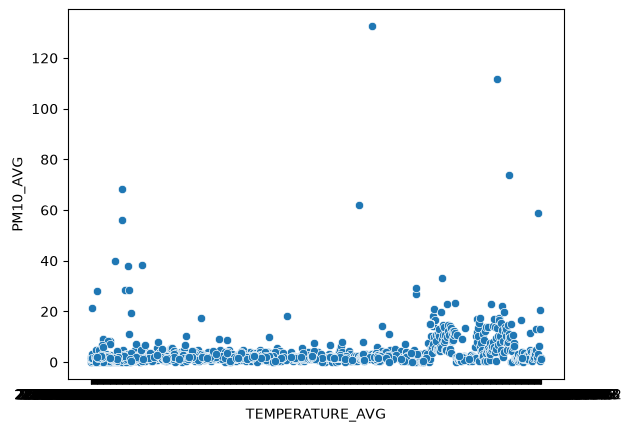

In [50]:
sns.scatterplot(data=df_smog, x='TEMPERATURE_AVG', y='PM10_AVG')       


Analiza opisowa

In [83]:
skim(df_smog)


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1614   │ │ string      │ 9     │                                                          │
│ │ Number of columns │ 14     │ │ float64     │ 4     │                                                          │
│ └───────────────────┴────────┘ │ object      │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column       ┃ NA  ┃ NA %   ┃ mean    ┃ sd      ┃ p0       ┃ p25     ┃ p50     ┃ p75    ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │  LONGITUDE   │   0 │      0 │   18.89 │   4.856 │   -157.5 │   17.01 │   19.02 │  20.68 │  23.87 │      ▇  │  │
│ │   LATITUDE   │   0 │      0 │   51.31 │    1.78 │    1.859 │   50.14 │   51.13 │  52.39 │  54.66 │      ▇  │  │
│ │   PM10_AVG   │   0 │      0 │   3.623 │   6.862 │        0 │   1.525 │   2.017 │  2.757 │  132.6 │    ▇    │  │
│ │   PM25_AVG   │   0 │      0 │   2.266 │   4.401 │        0 │   1.167 │   1.482 │  2.075 │  86.35 │    ▇    │  │
│ └──────────────┴─────┴────────┴─────────┴─────────┴──────────┴─────────┴─────────┴────────┴────────┴─────────┘  │
│                                            <class 'datetime.date'>                                              │
│ ┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column               ┃ NA     ┃ NA %      ┃ first                ┃ last                ┃ frequency         ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩  │
│ │      TYLKO_DATA      │      0 │         0 │ 2026-07-03           │ 2026-07-03          │ None              │  │
│ └──────────────────────┴────────┴───────────┴──────────────────────┴─────────────────────┴───────────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │   NAME    │  0 │    0 │   TEST    │  LICEUM   │ AKADEMIA  │ ŚWIETLICA │      54.4 │       7.8 │      12522 │  │
│ │           │    │      │  SZKOŁA   │ OGÓLNOKSZ │ NAJMŁODSZ │  WIEJSKA  │           │           │            │  │
│ │           │    │      │           │  TAŁCĄCE  │    YCH    │ ZŁOTKOWO  │           │           │            │  │
│ │           │    │      │           │ SPECJALNE │ KRZYSZTOF │           │           │           │            │  │
│ │           │    │      │           │ NR XXXII  │   GOŁAŚ   │           │           │           │            │  │
│ │           │    │      │           │    DLA    │ NIEP

In [ ]:
Zliczamy ilośc pomiarów dla każdej wartości PM10 w danych:


In [ ]:
df_smog['PM10_AVG'].value_counts()


Definiujemy prostą funkcję do obliczenia współczynnika zmienności (w procentach)


In [125]:
def wsp_zmiennosci(x):
    return (x.std() / x.mean()) * 100


Wywołujemy interesujące nas statystyki dla konkretnej kolumny (lub kilku kolumn)

In [137]:
statystyki = df_smog[['PM10_AVG']].agg([
    'mean',                   # Średnia
    'median',                 # Mediana (Q2)
    'std',                    # Odchylenie standardowe
    wsp_zmiennosci,           # Współczynnik zmienności (nasza funkcja)
    lambda x: x.quantile(0.25), # Q1
    lambda x: x.quantile(0.75)  # Q3
    ])


Najwyższe zanieczyszczenie

In [ ]:
top_5 = df_smog.nlargest(5, 'PM10_AVG')
display(top_5)


Najnizsze zanieczyszczenie

In [ ]:
bottom_5 = df_smog.nsmallest(5, 'PM10_AVG')
display(bottom_5)


In [134]:
print(statystyki)


                  PM10_AVG
mean              3.622694
median            2.016667
std               6.862440
wsp_zmiennosci  189.429172
<lambda>          1.525000
<lambda>          2.757386


Wyniki:
Średnia (mean) wynosi ok. 3.62, podczas gdy mediana (median) to zaledwie 2.02.
Interpretacja: Mediana mówi nam, że w dokładnie połowie badanych przypadków zanieczyszczenie pyłem PM10 wynosiło zaledwie 2.02 lub mniej. Dobowa norma alarmowa to 50. Ponieważ średnia jest zauważalnie wyższa od mediany, mamy tu do czynienia z rozkładem silnie prawoskośnym. Oznacza to, że przez większość czasu powietrze jest bardzo czyste, ale występują nagłe, rzadkie godziny z gigantycznym smogiem, które matematycznie "ciągną" średnią w górę.

Odchylenie standardowe (std) wynosi 6.86, a współczynnik zmienności osiągnął 189%.
Interpretacja: Współczynnik zmienności powyżej 100% oznacza ekstremalnie wysoki rozrzut danych. Odchylenie standardowe jest prawie dwukrotnie wyższe od samej średniej. Zjawisko smogu jest niestabilne i epizodyczne.

Dolny kwartyl (Q1) to 1.52, a górny kwartyl (Q3) to 2.75.
Interpretacja: Te liczby oznaczają, że aż połowa (środkowe 50%) wszystkich zebranych pomiarów jest w przedziale między 1.52 a 2.75.Q3 wynosi 2.75, co oznacza, że aż 75% wszystkich pomiarów jest niższych niż 2.75.Problemy ze smogiem (i za podwyższoną średnią oraz ogromne odchylenie) odpowiada najwyższe 25% pomiarów.

### Save dataframe to csv file **Always put as a last cell !**

In [158]:
ts = dt.datetime.now().strftime("%Y%m%d_%H-%M")
#df_smog.to_csv(f"../tests/smog_raw{ts}.csv", index=False)
#df_smog2.to_csv(f"../tests/smog2_raw{ts}.csv", index=False)
#df_polish.to_csv(f"../tests/smog_polishraw{ts}.csv", index=False, encoding='utf-8-sig')
